In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/Users/ainsleylewis/Downloads/OnlineWebFonts_COM_a9caff0fca25a51bf0e0e70e639b2a11/Harding Text Web Regular Regular/Harding Text Web Regular Regular.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()
plt.rcParams["font.family"] = font_name
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from astropy.io import fits
import re
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image

def combine_pngs_horizontal(image1_path, image2_path, output_path):
    """Combines two PNG images by switching width/height (stack vertically with matched width)."""
    img1 = Image.open(image1_path).convert('RGBA')
    img2 = Image.open(image2_path).convert('RGBA')

    # Ensure both images have the same width for seamless combination
    min_width = min(img1.width, img2.width)
    img1 = img1.resize((min_width, int(img1.height * min_width / img1.width)))
    img2 = img2.resize((min_width, int(img2.height * min_width / img2.width)))

    # Create a new blank image with the common width and combined height (stack vertically)
    combined_height = img1.height + img2.height
    combined_image = Image.new('RGBA', (min_width, combined_height))

    # Paste the images onto the new canvas (one above the other)
    combined_image.paste(img1, (0, 0))
    combined_image.paste(img2, (0, img1.height))

    # Save the combined image
    combined_image.save(output_path)
    print(f"Combined image saved to {output_path}")

def plot_parameter_table(sections, precision=3, bkg='white', save_prefix=None, dpi=300):
    table_data = []
    header_indices = []
    data_indices = []

    for header, rows in sections:
        header_indices.append(len(table_data))
        table_data.append([header])
        start_index = len(table_data)
        data_indices.extend(range(start_index, start_index + len(rows)))
        formatted_rows = []
        for row in rows:
            if row and str(row[0]).strip().lower() == 'flags':
                formatted_rows.append([str(val) for val in row])
                continue
            formatted_row = []
            for val in row:
                try:
                    num = float(val)
                    if np.isnan(num):
                        formatted_row.append("NaN")
                    else:
                        formatted_row.append(f"{num:.{precision}f}")
                except (ValueError, TypeError):
                    formatted_row.append(str(val))
            formatted_rows.append(formatted_row)
        table_data.extend(formatted_rows)

    if not table_data:
        print("No data to plot.")
        return

    max_cols = max(len(row) for row in table_data)
    for row in table_data:
        row.extend([''] * (max_cols - len(row)))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.axis('tight')
    ax.axis('off')
    the_table = ax.table(cellText=table_data, loc='center', cellLoc='left')
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(10)
    the_table.scale(1.1, 1.4)

    col_width = 1.0 / max_cols
    for j in range(max_cols):
        for i in range(len(table_data)):
            the_table[(i, j)].set_width(col_width)

    for header_idx in header_indices:
        for j in range(max_cols):
            cell = the_table[(header_idx, j)]
            cell.set_facecolor("#434343" if bkg == 'white' else "#ffffff")
            cell.set_text_props(weight='bold', color='black' if bkg == 'black' else 'white', ha='center', fontsize=12)
            cell.visible_edges = "horizontal"
            cell.set_edgecolor('white' if bkg == 'white' else 'black')
        the_table[(header_idx, 0)].visible_edges = "closed"

    for data_idx in data_indices:
        for j in range(max_cols):
            cell = the_table[(data_idx, j)]
            text = cell.get_text().get_text()
            cell.set_facecolor("#e9e9e9" if bkg == 'white' else '#2e2e2e')
            cell.set_edgecolor('white' if bkg == 'white' else 'black')
            cell.set_text_props(color='black' if bkg == 'white' else 'white', fontsize=10)
            first_cell_text = ''
            try:
                first_cell_text = the_table[(data_idx, 0)].get_text().get_text()
            except Exception:
                first_cell_text = table_data[data_idx][0] if table_data and len(table_data) > data_idx else ''
            if str(first_cell_text).strip() not in ['Input', 'Optimized', 'Flags', '']:
                cell.set_facecolor("#b9b9b9" if bkg == 'white' else "#5f5f5f")
                cell.set_text_props(weight='bold')
            try:
                float(text)
                cell._text.set_ha('center')
            except ValueError:
                cell._text.set_ha('center')

    plt.title("Model Parameters Summary", pad = 50, fontsize=10, weight='bold')
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'{save_prefix}_model_parameters_table.png', dpi=dpi, bbox_inches='tight')
    plt.show()

def calculate_distance(row1, row2):
    return np.sqrt((row1['x'] - row2['x'])**2 + (row1['y'] - row2['y'])**2)

def extract_setup_plotting(obs_file, crit_file, lens_file, optresult_file, point_file, model_file, bkg='white', **flags):
    # Extract params from model file
    with open(model_file, 'r') as f:
        model_lines = f.readlines()
    
    # Default cosmology and setup values
    omega, lambdac, weos, h0, x_low, y_low, x_up, y_up, exten_pix, point_pix = 0.3, 0.7, -1.0, 0.7, -3.5, -3.5, 3.5, 3.5, 0.05, 0.05
    usemag = 0
    varyh0 = 0
    flux_obs_pos = 0
    mag_ratio = 0
    
    initial_guesses = []
    param_flags = []
    models_used = []
    source_guess = []
    source_flags = []
    
    for line in model_lines:
        if 'glafic.init(' in line:
            m = re.search(r'glafic\.init\(([^)]+)\)', line)
            if m:
                args = [arg.strip() for arg in m.group(1).split(',')]
                if len(args) >= 11:
                    omega, lambdac, weos, h0 = float(args[0]), float(args[1]), float(args[2]), float(args[3])
                    x_low, y_low, x_up, y_up = float(args[5]), float(args[6]), float(args[7]), float(args[8])
                    exten_pix, point_pix = float(args[9]), float(args[10])
        elif 'chi2_usemag' in line:
            m = re.search(r'chi2_usemag\s+(\d+)', line)
            if m: usemag = int(m.group(1))
        elif 'hvary' in line:
            m = re.search(r'hvary\s+(\d+)', line)
            if m: varyh0 = int(m.group(1))
        # Handle set_lens
        elif 'glafic.set_lens(' in line:
            m = re.search(r"glafic\.set_lens\(\s*\d+\s*,\s*'([^']+)'\s*,(.*)\)", line)
            if m:
                models_used.append(m.group(1).upper())
                initial_guesses.append([x.strip() for x in m.group(2).split(',')])
        elif 'glafic.setopt_lens(' in line:
            m = re.search(r"glafic\.setopt_lens\(\s*\d+\s*,(.*)\)", line)
            if m:
                param_flags.append([x.strip() for x in m.group(1).split(',')])
        elif 'glafic.set_point(' in line:
            m = re.search(r"glafic\.set_point\(\s*\d+\s*,(.*)\)", line)
            if m:
                source_guess = [x.strip() for x in m.group(1).split(',')]
        elif 'glafic.setopt_point(' in line:
            m = re.search(r"glafic\.setopt_point\(\s*\d+\s*,(.*)\)", line)
            if m:
                source_flags = [x.strip() for x in m.group(1).split(',')]

    if source_guess:
        initial_guesses.append(source_guess)
        param_flags.append(source_flags)

    model_params_dict = {
        'POW': ['$z_{s,fid}$', 'x', 'y', 'e', '$\\theta_{e}$', '$r_{Ein}$', '$\\gamma (PWI)$'],
        'SIE': ['$\\sigma$', 'x', 'y', 'e', '$\\theta_{e}$', '$r_{core}$', 'NaN'],
        'ANFW': ['M', 'x', 'y', 'e', '$\\theta_{e}$', 'c or $r_{s}$', 'NaN'],
        'EIN': ['M', 'x', 'y', 'e', '$\\theta_{e}$', 'c or $r_{s}$', r'$\alpha_{e}$'],
        'PERT': ['$z_{s,fid}$', 'x', 'y', '$\\gamma$', '$\\theta_{\\gamma}$', 'NaN', '$\\kappa$'],
        'SERS': ['$M_{tot}$', 'x', 'y', 'e', '$\\theta_{e}$', '$r_{e}$', '$n$'],
        'MPOLE': ['$z_{s,fid}$', 'x', 'y', '$\\eta$', '$\\theta_{m}$', 'm', 'n']
    }

    # 1. Load OBS file
    obs_columns = ['x', 'y', 'mag', 'pos_err', 'mag_err', 'td', 'td_err', 'parity']
    obs_point = pd.read_csv(obs_file, skiprows=1, header=None, names=obs_columns, delim_whitespace=True)
    first_row = pd.read_csv(obs_file, nrows=1, header=None, names=['id', 'n_img', 'zs', 'zs_err'], delim_whitespace=True)
    n_img = first_row['n_img'][0]
    zs = first_row['zs'][0]
    
    brightest_index = obs_point['mag'].idxmax()
    obs_point.at[brightest_index, 'Img'] = 'A'
    names = ['A', 'B', 'C', 'D']
    current_name_index = 0
    current_index = brightest_index
    assigned_indices = {current_index}
    while len(assigned_indices) < len(obs_point) and current_name_index < len(names) - 1:
        current_x, current_y = obs_point.at[current_index, 'x'], obs_point.at[current_index, 'y']
        next_index = None; max_angle = -float('inf')
        for i in range(len(obs_point)):
            if i in assigned_indices: continue
            angle = np.arctan2(obs_point.at[i, 'y'] - current_y, obs_point.at[i, 'x'] - current_x)
            if angle > max_angle:
                max_angle = angle
                next_index = i
        if next_index is not None:
            current_name_index += 1
            obs_point.at[next_index, 'Img'] = names[current_name_index]
            assigned_indices.add(next_index)
            current_index = next_index

    obs_point['Color'] = ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple'][:len(obs_point)]
    obs_point = obs_point.sort_values(by='Img').reset_index(drop=True)
    
    # 2. Load Point Dat (predicted)
    pred_point = pd.read_csv(point_file, skiprows=1, header=None, delim_whitespace=True, names=['x', 'y', 'mag', 'td'])
    num_pred_images = len(pred_point)
    distance_matrix = np.zeros((n_img, num_pred_images))
    for i in range(n_img):
        for j in range(num_pred_images):
            distance_matrix[i, j] = calculate_distance(obs_point.iloc[i], pred_point.iloc[j])
    
    matched_indices = np.unravel_index(np.argsort(distance_matrix, axis=None), distance_matrix.shape)
    matched_pred_indices = set()
    matched_obs_indices = set()
    matches = []
    for obs_idx, pred_idx in zip(*matched_indices):
        if obs_idx not in matched_obs_indices and pred_idx not in matched_pred_indices:
            matches.append((obs_idx, pred_idx))
            matched_obs_indices.add(obs_idx)
            matched_pred_indices.add(pred_idx)
        if len(matches) == min(n_img, num_pred_images):
            break
    matches.sort(key=lambda x: x[0])
    matched_pred_list = [pred_idx for _, pred_idx in matches]
    pred_point = pred_point.iloc[matched_pred_list].reset_index(drop=True)
    pred_point['Img'] = [obs_point.at[obs_idx, 'Img'] for obs_idx, _ in matches]
    pred_point = pred_point.sort_values(by='Img').reset_index(drop=True)

    color_map = obs_point.set_index('Img')['Color'].to_dict()
    pred_point['Color'] = pred_point['Img'].map(color_map)
    
    image_rms = []
    for i in range(len(pred_point)):
        obs_row = obs_point[obs_point['Img'] == pred_point.at[i, 'Img']].iloc[0]
        dist = np.sqrt((obs_row['x'] - pred_point.at[i, 'x'])**2 + (obs_row['y'] - pred_point.at[i, 'y'])**2)
        image_rms.append(dist)
    pos_rms = np.sqrt(np.sum(np.array(image_rms)**2) / len(pred_point))
    pred_point['pos_rms'] = image_rms

    # 3. Load Lens FITS 
    lens_hdu = fits.open(lens_file)
    lens_data = lens_hdu[0].data
    lens_hdu.close()
    alpha_x, alpha_y = lens_data[0], lens_data[1]
    td_map, kappa = lens_data[2], lens_data[3]
    mag_map = lens_data[6]
    flux_map = 1 / mag_map

    for i in range(len(pred_point)):
        img = pred_point.at[i, 'Img']
        obs_row = obs_point[obs_point['Img'] == img].iloc[0]
        x_pos, y_pos = obs_row['x'], obs_row['y']
        x_pos_pix = int(round((x_pos - x_low)/(x_up - x_low) * flux_map.shape[1])) if x_up != x_low else 0
        y_pos_pix = int(round((y_pos - y_low)/(y_up - y_low) * flux_map.shape[0])) if y_up != y_low else 0
        x_pos_pix = min(max(x_pos_pix, 0), flux_map.shape[1]-1)
        y_pos_pix = min(max(y_pos_pix, 0), flux_map.shape[0]-1)
        pred_point.at[i, 'mag_at_obs'] = flux_map[y_pos_pix, x_pos_pix]
        x_pos_err = obs_row['pos_err']
        y_pos_err = obs_row['pos_err']
        pred_point.at[i, 'mag_at_upper'] = pred_point.at[i, 'mag_at_obs']
        pred_point.at[i, 'mag_at_lower'] = pred_point.at[i, 'mag_at_obs']

    pred_point['mag'] = abs(pred_point['mag'])
    if usemag == 0:
        pred_point['mag'] = pred_point['mag']/max(pred_point['mag']) if max(pred_point['mag']) != 0 else 0
        pred_point['mag_at_obs'] = abs(pred_point['mag_at_obs']/max(pred_point['mag_at_obs'])) if max(pred_point['mag_at_obs']) != 0 else 0
    elif usemag == 1 and mag_ratio == 1:
        pred_point['mag'] = abs(pred_point['mag']/max(pred_point['mag'])) if max(pred_point['mag']) != 0 else 0
        pred_point['mag_at_obs'] = abs(pred_point['mag_at_obs']/max(pred_point['mag_at_obs'])) if max(pred_point['mag_at_obs']) != 0 else 0

    flux_rms_arr = []
    percentage_errors = []
    for i in range(len(pred_point)):
        img = pred_point.at[i, 'Img']
        obs_row = obs_point[obs_point['Img'] == img].iloc[0]
        diff = pred_point.at[i, 'mag'] - obs_row['mag']
        flux_rms_arr.append(diff)
        perc_error = abs((pred_point.at[i, 'mag'] - obs_row['mag']) / obs_row['mag']) * 100 if obs_row['mag'] != 0 else 0
        percentage_errors.append(perc_error)
    flux_rms_value = np.sqrt(np.sum(np.array(flux_rms_arr)**2) / len(pred_point)) if len(pred_point) else 0
    avg_percentage_error = np.mean(percentage_errors) if percentage_errors else 0
    pred_point['flux_rms'] = flux_rms_arr
    pred_point['percentage_error'] = percentage_errors

    # 4. Critical Curves - raw data, no interpolation
    crit_data = pd.read_csv(crit_file, header=None, delim_whitespace=True, names=['xi_1', 'yi_1', 'xs_1', 'ys_1', 'x1i_2', 'yi_2', 'xs_2', 'ys_2'])

    # Deflection field data
    alpha_mag = np.sqrt(alpha_x**2 + alpha_y**2)
    ny, nx = alpha_x.shape
    x_grid = np.linspace(x_low, x_up, nx)
    y_grid = np.linspace(y_low, y_up, ny)
    X, Y = np.meshgrid(x_grid, y_grid)
    step = max(1, nx // 12)
    Xs, Ys = X[::step, ::step], Y[::step, ::step]
    # Normalise arrows to unit length for uniform display
    Us_raw, Vs_raw = alpha_x[::step, ::step], alpha_y[::step, ::step]
    arrow_mag = np.sqrt(Us_raw**2 + Vs_raw**2)
    arrow_mag[arrow_mag == 0] = 1  # avoid division by zero
    Us_norm = Us_raw / arrow_mag
    Vs_norm = Vs_raw / arrow_mag
    
    kappa_min = np.min(kappa)
    kappa = kappa + abs(kappa_min)

    constraint = flags.get('constraint', 'td')
    td_rms = 0; avg_percentage_error_td = 0
    if 'td' in constraint:
        for i in range(len(pred_point)):
            img = pred_point.at[i, 'Img']
            obs_row = obs_point[obs_point['Img'] == img].iloc[0]
            pred_point.at[i, 'td_rms'] = pred_point.at[i, 'td'] - obs_row['td']
        percentage_errors_td = [abs(pred_point.at[i, 'td_rms'] / obs_point[obs_point['Img'] == pred_point.at[i, 'Img']].iloc[0]['td']) * 100 if obs_point[obs_point['Img'] == pred_point.at[i, 'Img']].iloc[0]['td'] != 0 else 0 for i in range(len(pred_point))]
        pred_point['td_percentage_error'] = percentage_errors_td
        avg_percentage_error_td = np.mean(percentage_errors_td) if percentage_errors_td else 0
        td_rms = np.sqrt(np.sum(pred_point['td_rms']**2) / len(pred_point)) if len(pred_point) else 0

    # 5. Optimization Results
    with open(optresult_file, 'r') as file: opt_result = file.readlines()
    last_optimize_index = max([i for i, line in enumerate(opt_result) if 'optimize' in line], default=-1)
    if last_optimize_index >= 0: opt_result = opt_result[last_optimize_index + 1:]
    
    opt_lens_params = []
    for line in opt_result:
        if line.startswith('lens'):
            parts = line.strip().split()
            opt_lens_params.append((parts[1], [float(x) for x in parts[2:]]))
    
    opt_source_params = []
    for line in opt_result:
        if line.startswith('point'):
            opt_source_params.append([float(x) for x in line.strip().split()[1:]])
    
    # Table setup
    first_header = 'Cosmology'
    first_row_cosmo = [f'$\\omega$ = {omega}', f'$\\Lambda$ = {lambdac}', f'$w$ = {weos}', f'$H_0$ = {(h0 * 100):.2f}']
    second_header = 'Lens Model'
    all_lens_model_rows = []
    
    num_lens = len(models_used)
    for i in range(num_lens):
        model_name = models_used[i]
        param_names_row = [model_name] + ['$z_{lens}$'] + model_params_dict.get(model_name, [])
        val_in = initial_guesses[i] if i < len(initial_guesses) else []
        initial_values_row = ['Input'] + [f'{float(p):.3f}' for p in val_in]
        optimized_params = [f'{p:.3f}' for p in opt_lens_params[i][1]] if i < len(opt_lens_params) else []
        optimized_values_row = ['Optimized'] + optimized_params
        flags_row = ['Flags'] + (param_flags[i] if i < len(param_flags) else [])
        if i > 0: all_lens_model_rows.append([''])
        all_lens_model_rows.extend([param_names_row, initial_values_row, optimized_values_row, flags_row])
    
    source_header = 'Source'
    source_model_rows = []
    source_param_names_row = ['Source', '$z_{source}$', 'x', 'y']
    val_in = initial_guesses[-1] if len(initial_guesses) > num_lens else []
    source_initial_values_row = ['Input'] + [f'{float(p):.3f}' for p in val_in]
    optimized_source_params_vals = [f'{p:.3f}' for p in opt_source_params[0]] if opt_source_params else []
    source_optimized_values_row = ['Optimized'] + optimized_source_params_vals
    source_flags_row = ['Flags'] + (param_flags[-1] if len(param_flags) > num_lens else [])
    source_model_rows.extend([source_param_names_row, source_initial_values_row, source_optimized_values_row, source_flags_row])
    sections_to_plot = [(first_header, [first_row_cosmo]), (second_header, all_lens_model_rows), (source_header, source_model_rows)]

    # Return all context extracted
    context = {
        'obs_point': obs_point,
        'pred_point': pred_point,
        'bkg': bkg,
        'pos_rms': pos_rms,
        'flux_rms_value': flux_rms_value,
        'avg_percentage_error': avg_percentage_error,
        'usemag': usemag,
        'mag_ratio': mag_ratio,
        'flux_obs_pos': flux_obs_pos,
        'crit_data': crit_data,
        'source_params': opt_source_params, 
        'lens_params': opt_lens_params, 
        'kappa': kappa, 'x_low': x_low, 'x_up': x_up, 'y_low': y_low, 'y_up': y_up,
        'constraints': constraint, 'td_rms': td_rms, 'avg_percentage_error_td': avg_percentage_error_td,
        'sections_to_plot': sections_to_plot,
        'Xs': Xs, 'Ys': Ys, 'Us': Us_norm, 'Vs': Vs_norm,
        'alpha_mag': alpha_mag,
        'alpha_x': alpha_x, 'alpha_y': alpha_y,
    }
    context.update(flags)
    return context

# -----------------------------------------------------------------------
# Individual plot helpers (used by both combined and separate modes)
# -----------------------------------------------------------------------

def _plot_posrms(ax, context):
    obs_point = context['obs_point']
    pred_point = context['pred_point']
    bkg = context['bkg']
    bar_width = 0.4 if len(obs_point) < 4 else 0.5
    scaling = 0.1
    bar_container = ax.bar(pred_point['Img'], pred_point['pos_rms'], color=pred_point['Color'], width=bar_width, edgecolor='black' if bkg == 'white' else 'white')
    legend_label_added = False
    for i, bar_patch in enumerate(bar_container.patches):
        img_name = pred_point['Img'].iloc[i]
        obs_error = obs_point.loc[obs_point['Img'] == img_name, 'pos_err'].values[0]
        xmin_rel = (bar_patch.get_x() - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0])
        xmax_rel = (bar_patch.get_x() + bar_patch.get_width() - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0])
        ax.axhline(y=obs_error, xmin=xmin_rel, xmax=xmax_rel, color='r', linestyle='--', linewidth=2, label='' if legend_label_added else '$1 \\sigma$')
        legend_label_added = True
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + scaling * (ax.get_ylim()[1] - ax.get_ylim()[0]))
    ax.set_xlabel('Image')
    ax.set_ylabel('Position Offset')
    if legend_label_added: ax.legend(fontsize='small')
    ax.set_title(f'Position RMS = {context.get("pos_rms", 0):.4f}"')

def _plot_fluxrms(ax, context):
    obs_point = context['obs_point']
    pred_point = context['pred_point']
    bkg = context['bkg']
    scaling = 0.1
    x = np.arange(len(obs_point['Img']))
    pred_indices = [list(obs_point['Img']).index(img) for img in pred_point['Img']]
    width = 0.3 if len(obs_point) < 4 else 0.35
    ax.bar(x + width/2, obs_point['mag'], width, label='Observed', color=obs_point['Color'], edgecolor='black' if bkg == 'white' else 'white')
    ax.errorbar(x + width/2, obs_point['mag'], yerr=obs_point['mag_err'], fmt='None', capsize=8, ecolor='white' if bkg == 'black' else 'black', label='$1 \\sigma$')
    ax.bar(np.array(pred_indices) - width/2, pred_point['mag'], width, label='Predicted', color=pred_point['Color'], hatch='//', edgecolor='white' if bkg == 'black' else 'black')
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + scaling * (ax.get_ylim()[1] - ax.get_ylim()[0]))
    ax.set_xticks(x); ax.set_xticklabels(obs_point['Img'])
    ax.legend(fontsize='small'); ax.set_xlabel('Image')
    if context.get('usemag') == 0:
        ax.set_ylabel('Flux Ratios'); ax.set_title(f'Flux Ratio RMS = {context.get("flux_rms_value", 0):.4f}')
    else:
        ax.set_ylabel('Absolute Magnification'); ax.set_title(f'Absolute Magnification RMS = {context.get("flux_rms_value", 0):.4f}')

def _plot_fluxpercent(ax, context):
    pred_point = context['pred_point']
    obs_point = context['obs_point']
    bkg = context['bkg']
    bar_width = 0.4 if len(obs_point) < 4 else 0.5
    scaling = 0.1
    ax.bar(pred_point['Img'], pred_point['percentage_error'], color=pred_point['Color'], width=bar_width, edgecolor='black' if bkg == 'white' else 'white')
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + scaling * (ax.get_ylim()[1] - ax.get_ylim()[0]))
    ax.set_xlabel('Image'); ax.set_ylabel('Percentage Error (%)')
    ax.set_title(f'Avg Percent Error = {context.get("avg_percentage_error", 0):.2f}%')

def _plot_critcurves(ax, context):
    bkg = context['bkg']
    obs_point = context['obs_point']
    pred_point = context['pred_point']
    crit_data = context['crit_data']
    # Plot raw scatter points directly from the crit.dat file
    ax.scatter(crit_data['xi_1'], crit_data['yi_1'], color='red', s=1, label='Critical Curves')
    ax.scatter(crit_data['x1i_2'], crit_data['yi_2'], color='red', s=1)
    ax.scatter(crit_data['xs_1'], crit_data['ys_1'], color='white' if bkg == 'black' else 'black', s=1, label='Caustics')
    ax.scatter(crit_data['xs_2'], crit_data['ys_2'], color='white' if bkg == 'black' else 'black', s=1)
    ax.scatter(obs_point['x'], obs_point['y'], color=obs_point['Color'], marker='x', s=80)
    ax.scatter(pred_point['x'], pred_point['y'], color=pred_point['Color'], marker='o', s=30)
    text_scaling = 0.01
    xmin, xmax = ax.get_xlim()
    for i in range(len(pred_point)):
        ax.text(pred_point.at[i, 'x'] + (text_scaling * (xmax - xmin)), pred_point.at[i, 'y'], pred_point.at[i, 'Img'], color='white' if bkg == 'black' else 'black', fontsize=12)
    ax.set_aspect('equal')
    ax.set_xlim(context['x_low'], context['x_up'])
    ax.set_ylim(context['y_low'], context['y_up'])
    ax.set_title('Critical Curves and Caustics')
    ax.legend(fontsize='small', markerscale=5)

def _plot_kappamap(ax, context):
    kappa = context['kappa']
    vmin = np.min(kappa[kappa > 0])
    vmax = np.max(kappa)
    im = ax.imshow(kappa, origin='lower', cmap='inferno',
                   norm=LogNorm(vmin=vmin, vmax=vmax),
                   extent=[context['x_low'], context['x_up'], context['y_low'], context['y_up']],
                   aspect='equal')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    plt.colorbar(im, cax=cax, label='Convergence ($\\kappa$)')
    levels = np.logspace(np.log10(vmin), np.log10(vmax), 10)
    ax.contour(kappa, levels=levels, colors='white', extent=[context['x_low'], context['x_up'], context['y_low'], context['y_up']], origin='lower', linewidths=1)
    ax.set_title('Convergence Map')

def _plot_timedelays(ax, context):
    obs_point = context['obs_point']
    pred_point = context['pred_point']
    bkg = context['bkg']
    scaling = 0.1
    x = np.arange(len(obs_point['Img']))
    pred_indices = [list(obs_point['Img']).index(img) for img in pred_point['Img']]
    width = 0.3 if len(obs_point) < 4 else 0.35
    ax.bar(x + width/2, obs_point['td'], width, label='Observed', color=obs_point['Color'], edgecolor='black' if bkg == 'white' else 'white')
    ax.errorbar(x + width/2, obs_point['td'], yerr=obs_point['td_err'], fmt='None', capsize=8, ecolor='white' if bkg == 'black' else 'black', label='$1 \\sigma$')
    ax.bar(np.array(pred_indices) - width/2, pred_point['td'], width, label='Predicted', color=pred_point['Color'], hatch='//', edgecolor='white' if bkg == 'black' else 'black')
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + scaling * (ax.get_ylim()[1] - ax.get_ylim()[0]))
    ax.set_xticks(x); ax.set_xticklabels(obs_point['Img'])
    ax.legend(fontsize='small'); ax.set_xlabel('Image'); ax.set_ylabel('Time Delay (days)')
    ax.set_title(f'Time Delay RMS = {context.get("td_rms", 0):.4f} days')

def _plot_timedelaypercent(ax, context):
    pred_point = context['pred_point']
    obs_point = context['obs_point']
    bkg = context['bkg']
    bar_width = 0.4 if len(obs_point) < 4 else 0.5
    scaling = 0.1
    ax.bar(pred_point['Img'], pred_point['td_percentage_error'], color=pred_point['Color'], width=bar_width, edgecolor='black' if bkg == 'white' else 'white')
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + scaling * (ax.get_ylim()[1] - ax.get_ylim()[0]))
    ax.set_xlabel('Image'); ax.set_ylabel('Percentage Error in Time Delays (%)')
    ax.set_title(f'Avg Time Delay Percent Error = {context.get("avg_percentage_error_td", 0):.2f}%')

def _plot_deflectionfield(ax, context):
    alpha_mag = context['alpha_mag']
    vmin = np.min(alpha_mag[alpha_mag > 0])
    vmax = np.max(alpha_mag)
    # Background colourmap of deflection magnitude
    im = ax.imshow(alpha_mag, origin='lower', cmap='autumn',
                   extent=[context['x_low'], context['x_up'], context['y_low'], context['y_up']],
                   aspect='equal')
    # Uniform-length black arrows
    if context.get('Xs') is not None and context.get('Vs') is not None:
        ax.quiver(context['Xs'], context['Ys'], context['Us'], context['Vs'],
                  color='black', scale=20, width=0.005, headwidth=4, headlength=4)
    ax.set_xlabel('X Position'); ax.set_ylabel('Y Position')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    plt.colorbar(im, cax=cax, label='Deflection Angle')
    ax.set_title('Deflection Angle Field')

# -----------------------------------------------------------------------

def combined_plot(**kwargs):
    context = kwargs
    obs_point = context['obs_point']
    pred_point = context['pred_point']
    bkg = context['bkg']
    is_combined = bool(context.get('combined', True))

    # Collect enabled plot specs: (flag_name, plot_func)
    plot_specs = [
        ('posrms', _plot_posrms),
        ('fluxrms', _plot_fluxrms),
        ('fluxpercent', _plot_fluxpercent),
        ('critcurves', _plot_critcurves),
        ('kappamap', _plot_kappamap),
        ('timedelays', _plot_timedelays),
        ('timedelaypercent', _plot_timedelaypercent),
        ('deflectionfield', _plot_deflectionfield),
    ]
    enabled = [(name, fn) for name, fn in plot_specs if context.get(name, True)]

    if not enabled and not context.get('table', True):
        return

    # Style setup
    if bkg == 'black':
        plt.style.use('dark_background')
        plt.rcParams.update({'axes.facecolor': 'black', 'figure.facecolor': 'black'})
    else:
        plt.style.use('default')
        plt.rcParams.update({'axes.facecolor': 'white', 'figure.facecolor': 'white'})
    plt.rcParams["font.family"] = font_name
    plt.rcParams["figure.dpi"] = context.get('dpi', 300)

    if enabled:
        if is_combined:
            # Combined mode: all subplots in one figure
            n_plots = len(enabled)
            ncols = min(4, n_plots)
            nrows = (n_plots + ncols - 1) // ncols
            fig = plt.figure(figsize=(22, 5 * nrows))
            gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.4, wspace=0.3)
            fig.subplots_adjust(left=0.05, right=0.97, top=0.90, bottom=0.05)
            axes_plots = [fig.add_subplot(gs[i // ncols, i % ncols]) for i in range(n_plots)]
            # Fill extra cells
            for extra_i in range(n_plots, nrows * ncols):
                ax_off = fig.add_subplot(gs[extra_i // ncols, extra_i % ncols])
                ax_off.axis('off')

            for (name, fn), ax in zip(enabled, axes_plots):
                fn(ax, context)

            fig.suptitle("Lens Model", fontsize=16, weight='bold')
            if context.get('save_prefix', None):
                plt.savefig(f'{context["save_prefix"]}_model_analysis_plots.png', dpi=context.get('dpi', 300), bbox_inches='tight')
            plt.show()
        else:
            # Separate mode: each plot in its own figure
            for name, fn in enabled:
                fig, ax = plt.subplots(figsize=(7, 5))
                fn(ax, context)
                fig.suptitle("Lens Model", fontsize=14, weight='bold')
                plt.tight_layout()
                plt.show()

    if context.get('table', True):
        plot_parameter_table(context['sections_to_plot'], bkg=bkg, save_prefix=context.get('save_prefix', None), dpi=context.get('dpi', 300))

def make_plots(obs_file, crit_file, lens_file, optresult_file, point_file, model_file, **flags):
    'Wrapper: reads files and generates all plots. Use keyword arguments to toggle plots. combined=True for one figure, False for separate.'
    defaults = {
        'posrms': True,
        'fluxrms': True,
        'fluxpercent': True,
        'critcurves': True,
        'kappamap': True,
        'timedelays': True,
        'timedelaypercent': True,
        'deflectionfield': True,
        'table': True,
        'combined': True,
    }
    defaults.update(flags)
    context = extract_setup_plotting(obs_file, crit_file, lens_file, optresult_file, point_file, model_file, **defaults)
    combined_plot(**context)


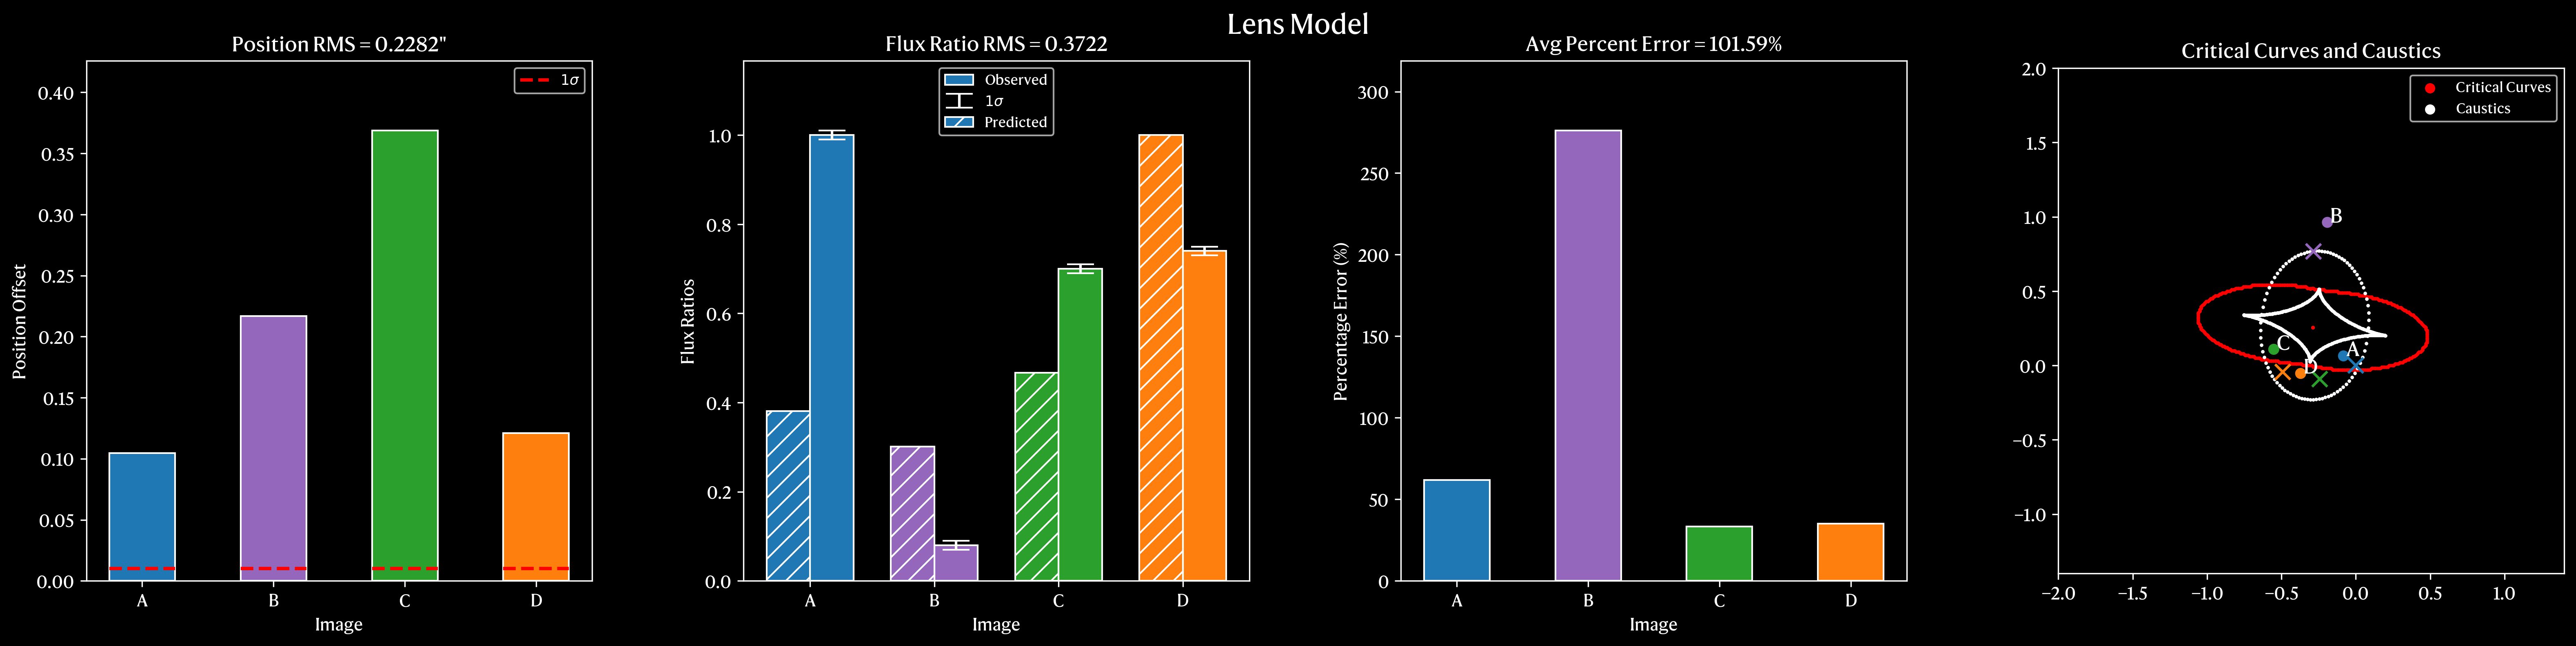

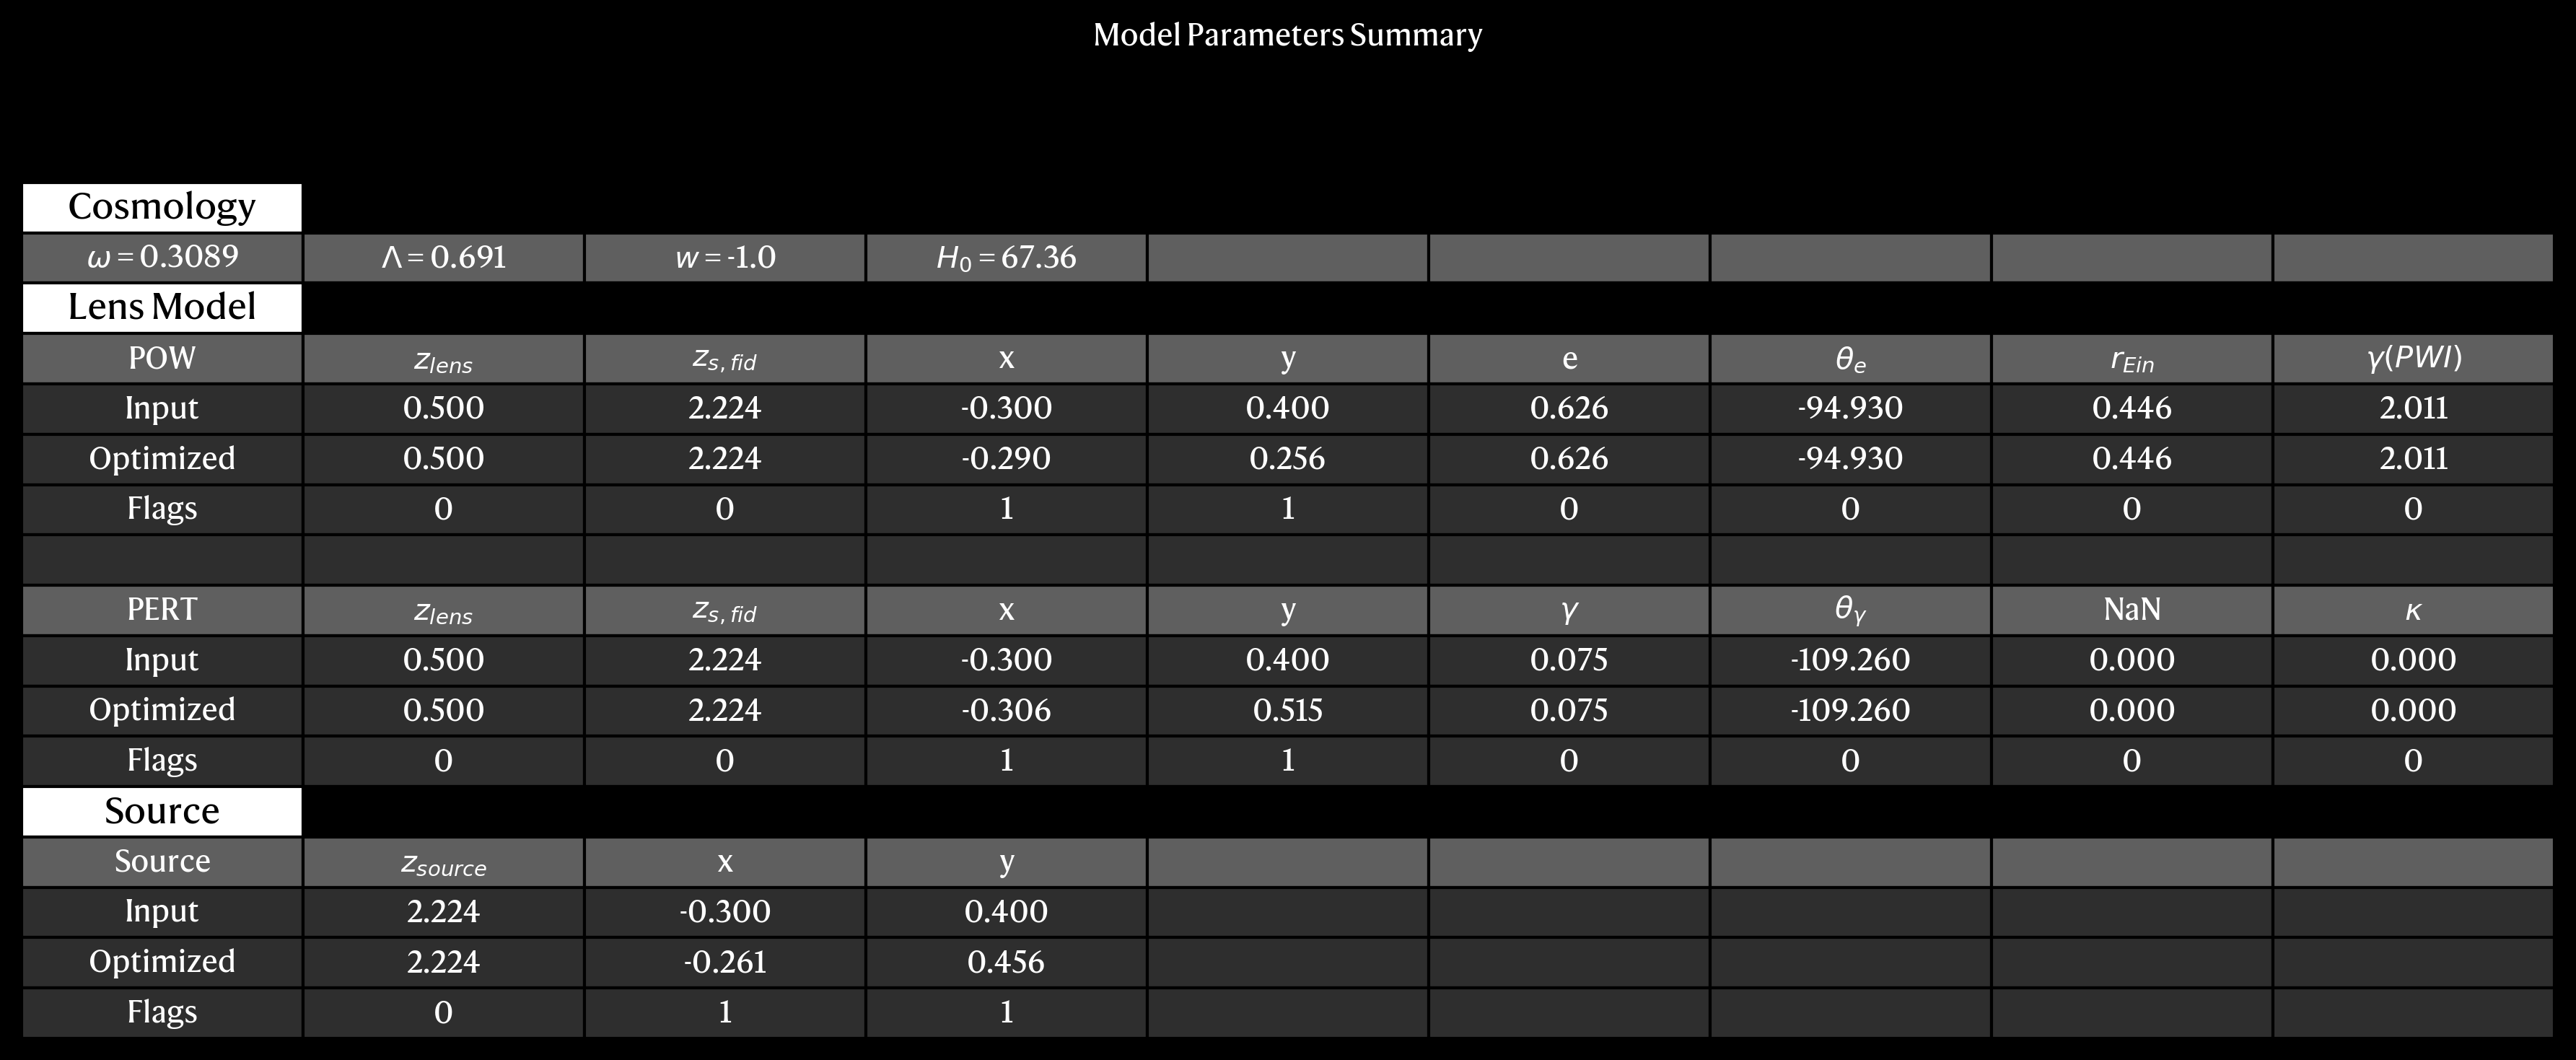

Combined image saved to Plots/pow_pos+flux_combined_model_analysis.png


In [40]:
# Example Usage:
save_prefix = 'Plots/pow_pos+flux'  # Set a prefix for saved plots
make_plots(
    obs_file='obs_pos+flux.dat',
    crit_file='Lens Models/pow_pos+flux_crit.dat',
    lens_file='Lens Models/pow_pos+flux_lens.fits',
    optresult_file='Lens Models/pow_pos+flux_optresult.dat',
    point_file='Lens Models/pow_pos+flux_point.dat',
    model_file='pow_pos+flux.py',
    # --- Flags (all default True, set False to disable) ---
    posrms=True,
    fluxrms=True,
    fluxpercent=True,
    critcurves=True,
    kappamap=False,
    timedelays=False,
    timedelaypercent=False,
    deflectionfield=False,
    table=True,
    combined=True,       # True = one figure; False = separate figures
    bkg='black',         # 'white' or 'black'
    save_prefix=save_prefix
)

combine_pngs_horizontal(f"{save_prefix}_model_analysis_plots.png", f"{save_prefix}_model_parameters_table.png", f"{save_prefix}_combined_model_analysis.png")